In [1]:
!pip install fastai annoy gdown --quiet
!pip install --upgrade gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cud

In [2]:
import os
import pandas as pd

# The exact path you found
BASE = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small"

# 1. Load the CSV
df = pd.read_csv(f"{BASE}/styles.csv", on_bad_lines="skip")

# 2. Create the correct image paths
img_folder = f"{BASE}/images/"
df["img_path"] = img_folder + df["id"].astype(str) + ".jpg"

# 3. CRITICAL: Filter out any missing images to prevent the FastAI 'NoneType' error
df = df[df["img_path"].apply(os.path.exists)]

print(f"✅ Success! Total valid images ready for FastAI: {len(df)}")

✅ Success! Total valid images ready for FastAI: 44419


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44419 entries, 0 to 44423
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44419 non-null  int64  
 1   gender              44419 non-null  object 
 2   masterCategory      44419 non-null  object 
 3   subCategory         44419 non-null  object 
 4   articleType         44419 non-null  object 
 5   baseColour          44404 non-null  object 
 6   season              44398 non-null  object 
 7   year                44418 non-null  float64
 8   usage               44102 non-null  object 
 9   productDisplayName  44412 non-null  object 
 10  img_path            44419 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 4.1+ MB


In [4]:
df[["id","masterCategory","subCategory","articleType"]].head(20)

,id,masterCategory,subCategory,articleType
0,15970,Apparel,Topwear,Shirts
1,39386,Apparel,Bottomwear,Jeans
2,59263,Accessories,Watches,Watches
3,21379,Apparel,Bottomwear,Track Pants
4,53759,Apparel,Topwear,Tshirts
5,1855,Apparel,Topwear,Tshirts
6,30805,Apparel,Topwear,Shirts
7,26960,Apparel,Topwear,Shirts
8,29114,Accessories,Socks,Socks
9,30039,Accessories,Watches,Watches


In [5]:
df["subCategory"].value_counts()

subCategory
Topwear                     15398
Shoes                        7343
Bags                         3055
Bottomwear                   2693
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree                         427
Nails                         329
Makeup                        307
Headwear                      293
Ties                          258
Accessories                   129
Scarves                       118
Cufflinks                     108
Apparel Set                   106
Free Gifts                    104
Stoles                         90
Skin Care                      77
Sk

In [6]:
import os
img_folder = f"{BASE}/images/"
df["img_path"]=img_folder+df["id"].astype(str)+".jpg"
df=df[df["img_path"].apply(os.path.exists)]
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,img_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,/kaggle/input/datasets/paramaggarwal/fashion-p...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...


In [7]:
df=df[["img_path","subCategory"]]
df.head()

,img_path,subCategory
0,/kaggle/input/datasets/paramaggarwal/fashion-p...,Topwear
1,/kaggle/input/datasets/paramaggarwal/fashion-p...,Bottomwear
2,/kaggle/input/datasets/paramaggarwal/fashion-p...,Watches
3,/kaggle/input/datasets/paramaggarwal/fashion-p...,Bottomwear
4,/kaggle/input/datasets/paramaggarwal/fashion-p...,Topwear


In [8]:
df[["subCategory"]]

,subCategory
0,Topwear
1,Bottomwear
2,Watches
3,Bottomwear
4,Topwear
...,...
44419,Shoes
44420,Flip Flops
44421,Topwear
44422,Fragrance


In [9]:
df[["subCategory"]].value_counts

<bound method DataFrame.value_counts of       subCategory
0         Topwear
1      Bottomwear
2         Watches
3      Bottomwear
4         Topwear
...           ...
44419       Shoes
44420  Flip Flops
44421     Topwear
44422   Fragrance
44423     Watches

[44419 rows x 1 columns]>

In [10]:
df[["subCategory"]].value_counts()


subCategory             
Topwear                     15398
Shoes                        7343
Bags                         3055
Bottomwear                   2693
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree                         427
Nails                         329
Makeup                        307
Headwear                      293
Ties                          258
Accessories                   129
Scarves                       118
Cufflinks                     108
Apparel Set                   106
Free Gifts                    104
Stoles                         90
Skin Care              

In [11]:
df["subCategory"].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
44419    False
44420    False
44421    False
44422    False
44423    False
Name: subCategory, Length: 44419, dtype: bool

In [12]:
df["subCategory"].isna().sum()

np.int64(0)

In [13]:
df[df["subCategory"].isna()]

,img_path,subCategory


In [14]:
df=df.dropna(subset=["subCategory"])
df.head()

,img_path,subCategory
0,/kaggle/input/datasets/paramaggarwal/fashion-p...,Topwear
1,/kaggle/input/datasets/paramaggarwal/fashion-p...,Bottomwear
2,/kaggle/input/datasets/paramaggarwal/fashion-p...,Watches
3,/kaggle/input/datasets/paramaggarwal/fashion-p...,Bottomwear
4,/kaggle/input/datasets/paramaggarwal/fashion-p...,Topwear


In [15]:
df["subCategory"].value_counts()

subCategory
Topwear                     15398
Shoes                        7343
Bags                         3055
Bottomwear                   2693
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree                         427
Nails                         329
Makeup                        307
Headwear                      293
Ties                          258
Accessories                   129
Scarves                       118
Cufflinks                     108
Apparel Set                   106
Free Gifts                    104
Stoles                         90
Skin Care                      77
Sk

In [16]:
count=df["subCategory"].value_counts()
valid_categories=count[count>=100].index.tolist()
df=df[df["subCategory"].isin(valid_categories)]
df.head()

,img_path,subCategory
0,/kaggle/input/datasets/paramaggarwal/fashion-p...,Topwear
1,/kaggle/input/datasets/paramaggarwal/fashion-p...,Bottomwear
2,/kaggle/input/datasets/paramaggarwal/fashion-p...,Watches
3,/kaggle/input/datasets/paramaggarwal/fashion-p...,Bottomwear
4,/kaggle/input/datasets/paramaggarwal/fashion-p...,Topwear


In [17]:
from fastai.vision.all import*

In [18]:
dblock=DataBlock(blocks=(ImageBlock,CategoryBlock),get_x=ColReader("img_path"),get_y=ColReader("subCategory"),splitter=RandomSplitter(valid_pct=0.2,seed=42),item_tfms=Resize(224))

In [19]:
dls=dblock.dataloaders(df,bs=64)

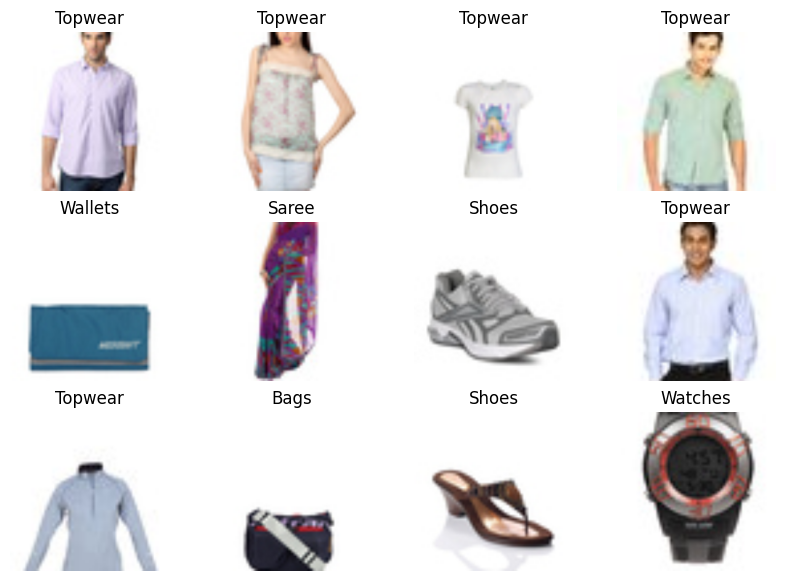

In [20]:
dls.show_batch(max_n=12,figsize=(10,7))

In [21]:
learn=vision_learner(dls,resnet18,metrics=accuracy)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


<div></div>

SuggestedLRs(valley=0.0010000000474974513)

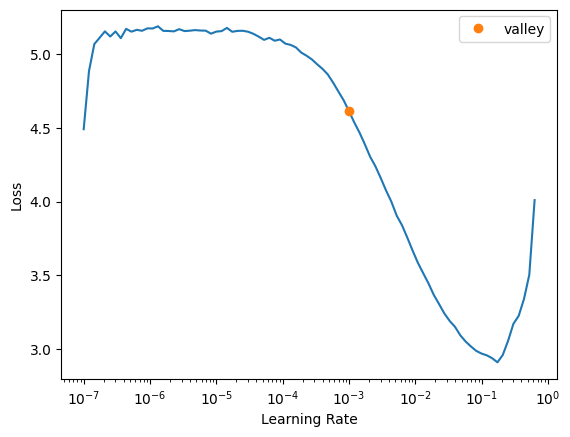

In [22]:
learn.lr_find()

In [23]:
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0)


(True, 'Tesla T4')

In [24]:
learn.fine_tune(3,base_lr=1.2e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.470720,0.294674,0.918012,01:33


epoch,train_loss,valid_loss,accuracy,time
0,0.256724,0.187427,0.952581,01:56
1,0.159754,0.142831,0.960541,01:58
2,0.094340,0.126391,0.965772,01:58


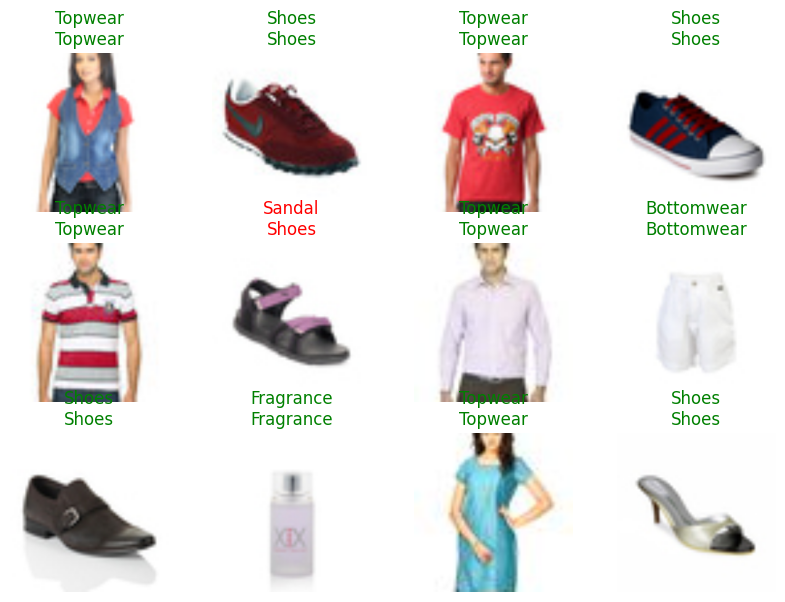

In [25]:
learn.show_results(max_n=12,figsize=(10,7))

In [26]:
import torch
penultimate=learn.model[1][-2]

class FeatureHook:
  def __init__(self,module):
    self.features=[]
    self.hook=module.register_forward_hook(self.hook_fn)

  def hook_fn(self,module,inp,out):
    x=out.detach().cpu()
    if x.ndim>2:
      x=x.mean(dim=[2,3])
    self.features.append(x)

  def close(self):
      self.hook.remove()
  def get_features(self):
      return torch.cat(self.features,dim=0)

In [27]:
all_paths=df["img_path"].tolist()
all_dl=dls.test_dl(all_paths,with_labels=False)
hook=FeatureHook(penultimate)
hook.features=[]
learn.model.eval()
device=learn.dls.device
with torch.no_grad():
    for batch in all_dl:
        imgs=batch[0].to(device)
        _=learn.model(imgs)
emb_tensor=hook.get_features()
hook.close()
embeddings=emb_tensor.numpy()
embeddings.shape

(43974, 512)

In [28]:
!pip install annoy

In [29]:
from annoy import AnnoyIndex

embedding_dim=embeddings.shape[1]
ann_index=AnnoyIndex(embedding_dim,'euclidean')

for i,vector in enumerate(embeddings):
    ann_index.add_item(i,vector)

ann_index.build(10)
ann_index.save("fashion_annoy.ann")


True

In [30]:
'''def show_similar(idx,n=5):
  print(f"Query image index:{idx}")
  neighbors=ann_index.get_nns_by_item(idx,n+1)[1:]

  print("Query image:")
  display(Image.open(df.iloc[idx]["img_path"]).resize((200,200)))

  print("\nSimilar item:")
  for i in neighbors:
    display(Image.open(df.iloc[i]["img_path"]).resize((200,200)))'''

'def show_similar(idx,n=5):\n  print(f"Query image index:{idx}")\n  neighbors=ann_index.get_nns_by_item(idx,n+1)[1:]\n\n  print("Query image:")\n  display(Image.open(df.iloc[idx]["img_path"]).resize((200,200)))\n\n  print("\nSimilar item:")\n  for i in neighbors:\n    display(Image.open(df.iloc[i]["img_path"]).resize((200,200)))'

In [31]:
'''show_similar(122,n=10)'''

'show_similar(122,n=10)'

In [32]:
from collections import defaultdict
category_to_indices=defaultdict(list)
for i,row in df.iterrows():
  cat=row["subCategory"]
  category_to_indices[cat].append(i)

In [33]:
def show_similar_filtered(idx,n=5):
  query_cat=df.iloc[idx]["subCategory"]
  print(f"Query image (Category:{query_cat}):")
  display(Image.open(df.iloc[idx]["img_path"]).resize((200,200)))
  candidates=category_to_indices[query_cat]
  neighbors=ann_index.get_nns_by_item(idx,50)
  filtered=[i for i in neighbors if i in candidates and i!=idx]
  if len(filtered)<n:
    print("/n Not enough same-category items,showing closest overall match instead:")
    filtered=[i for i in neighbors if i!=idx][:n]
  else:
    print("/nSimilar items in Same Category:")
  for i in filtered[:n]:
    display(Image.open(df.iloc[i]["img_path"]).resize((250,250)))

Query image (Category:Shoes):


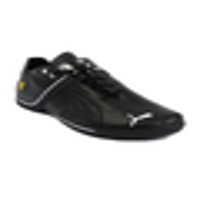

/n Not enough same-category items,showing closest overall match instead:


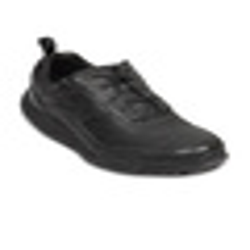

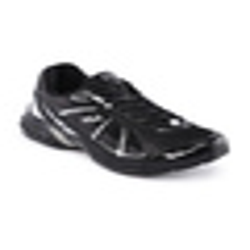

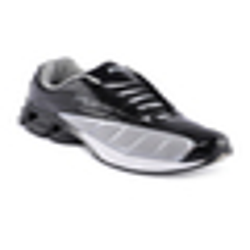

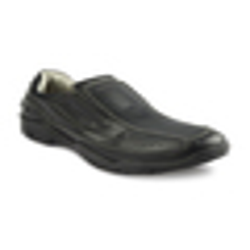

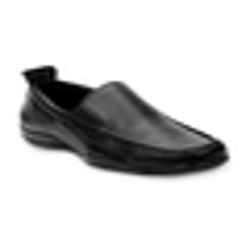

In [34]:
show_similar_filtered(10, n=5)

In [35]:
query_cat=df.iloc[10]["subCategory"]
print(query_cat)
category_to_indices[query_cat]

Shoes


[10,
 25,
 33,
 34,
 41,
 45,
 51,
 54,
 64,
 65,
 67,
 69,
 71,
 76,
 77,
 89,
 102,
 103,
 105,
 108,
 109,
 112,
 121,
 127,
 143,
 147,
 148,
 153,
 155,
 162,
 163,
 170,
 176,
 178,
 181,
 190,
 201,
 205,
 216,
 219,
 225,
 230,
 231,
 239,
 242,
 250,
 252,
 256,
 260,
 263,
 270,
 282,
 307,
 323,
 331,
 334,
 337,
 348,
 368,
 372,
 378,
 387,
 388,
 399,
 405,
 408,
 419,
 446,
 448,
 453,
 454,
 455,
 469,
 473,
 477,
 495,
 497,
 502,
 512,
 518,
 527,
 546,
 550,
 560,
 562,
 563,
 571,
 572,
 575,
 578,
 589,
 600,
 601,
 609,
 619,
 627,
 642,
 643,
 650,
 653,
 655,
 662,
 665,
 668,
 673,
 680,
 683,
 701,
 705,
 709,
 717,
 728,
 739,
 749,
 756,
 757,
 761,
 766,
 790,
 795,
 796,
 803,
 815,
 821,
 825,
 829,
 830,
 840,
 842,
 849,
 850,
 853,
 855,
 859,
 865,
 876,
 883,
 887,
 889,
 890,
 898,
 920,
 927,
 930,
 931,
 932,
 941,
 947,
 949,
 951,
 952,
 957,
 960,
 964,
 965,
 968,
 970,
 973,
 978,
 979,
 985,
 987,
 990,
 1002,
 1005,
 1006,
 1018,
 1019,
 10

In [36]:
def get_embedding_for_indices(indices):
  return embeddings[indices]

In [37]:
def vibe_match(indices,n=5):
  print("Selected images for vibes:")
  for idx in indices:
    display(Image.open(df.iloc[idx]["img_path"]).resize((200,200)))
  selected_embs=embeddings[indices]
  vibe_vector=selected_embs.mean(axis=0)
  neighbors=ann_index.get_nns_by_vector(vibe_vector,50)
  neighbors=[i for i in neighbors if i not in indices]
  print("\nRecommended items matching the combined vibe:")
  for i in neighbors[:n]:
    display(Image.open(df.iloc[i]["img_path"]).resize((200,200)))

Selected images for vibes:


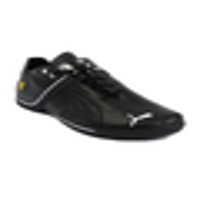

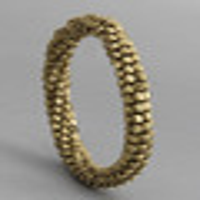

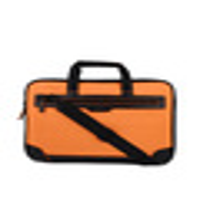


Recommended items matching the combined vibe:


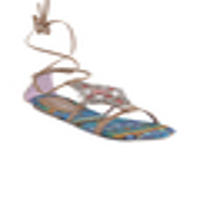

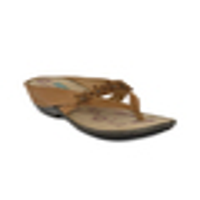

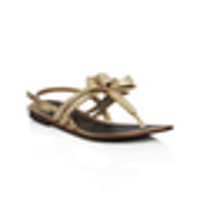

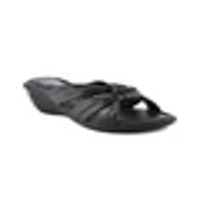

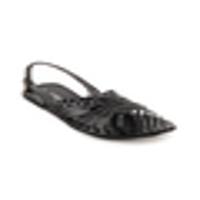

In [38]:
vibe_match([10, 25, 87], n=5)

In [39]:
from PIL import Image

def get_sim_img(idx,n=5):
  query_cat=df.iloc[idx]["subCategory"]
  query_path=df.iloc[idx]["img_path"]

  candidates=category_to_indices[query_cat]
  neighbors=ann_index.get_nns_by_item(idx,200)

  filtered=[i for i in neighbors if i in candidates and i!=idx]

  if len(filtered)<n:
    filtered=[i for i in neighbors if i!=idx][:n]
    title=f"not enough in'{query_cat}',showing closest overall"
  else:
    filtered=filtered[:n]
    title=f"Similar items in category '{query_cat}'"

  query_img=Image.open(query_path).resize((250,250))
  sim_imgs=[Image.open(df.iloc[i]["img_path"]).resize((250,250)) for i in filtered]

  return title,query_img,sim_imgs

In [40]:
def search_by_text(text):
  text=text.lower().strip()
  text_clean=text.replace("-","").replace(" ","").replace("_","")
  results=[]
  for idx, cat in df["subCategory"].items():
    cat_clean = cat.lower().replace("-", "").replace(" ", "").replace("_", "")
    if text_clean in cat_clean:
      results.append(idx)
  return results
def recom_from_text(text,n=5):
  idx_list=search_by_text(text)
  if len(idx_list)==0:
    return f"No matches found for '{text}'",None,[]
  first_idx=idx_list[0]
  return get_sim_img(first_idx,n)

In [41]:
from PIL import Image
from fastai.vision.all import *
import torch

def embed_uploaded_image(pil_img):
    # Embed a NEW image through the SAME penultimate-layer hook used to build the index (Cell 28)
    img = PILImage.create(pil_img)
    dl = learn.dls.test_dl([img])
    hook = FeatureHook(penultimate)   # 'penultimate' and FeatureHook come from Cell 28
    hook.features = []
    learn.model.eval()
    device = learn.dls.device
    with torch.no_grad():
        for batch in dl:
            _ = learn.model(batch[0].to(device))
    vec = hook.get_features()[0].numpy()
    hook.close()
    return vec

def recom_from_upload(pil_img, n=5):
    vec = embed_uploaded_image(pil_img)
    neighbors = ann_index.get_nns_by_vector(vec, n * 2)
    results = neighbors[:n]
    sim_imgs = [Image.open(df.iloc[i]["img_path"]).resize((250, 250)) for i in results]
    gallery = [(img, f"Similar #{i+1}") for i, img in enumerate(sim_imgs)]
    return "Similar items for uploaded image:", pil_img, gallery

In [42]:
import gradio as gr
from PIL import Image

def gradio_recom(idx,n):
    title,query_img,sim_imgs=get_sim_img(int(idx),int(n))
    gallery=[(img,f"Similar #{i+1}") for i,img in enumerate(sim_imgs)]
    return title,query_img,gallery

index_tab=gr.Interface(
    fn=gradio_recom,
    inputs=[
        gr.Slider(0,len(df)-1,value=10,step=1,label="Image Index"),
        gr.Slider(1,12,value=5,step=1,label="Number of Recommendations")
    ],
    outputs=[
        gr.Textbox(label="Info"),
        gr.Image(label="Query Image"),
        gr.Gallery(label="Recommended Items",columns=4,height="400px")
    ],
    title="Search by Index"
)

def gradio_recom_text(text,n):
    title,query_img,sim_imgs=recom_from_text(text,n)
    gallery=[(img,f"Match #{i+1}") for i,img in enumerate(sim_imgs)]
    return title,query_img,gallery

text_tab=gr.Interface(
    fn=gradio_recom_text,
    inputs=[
        gr.Textbox(label="Enter Category"),
        gr.Slider(1,12,value=5,step=1,label="Number of Recommendations")
    ],
    outputs=[
        gr.Textbox(label="Info"),
        gr.Image(label="Representative Image"),
        gr.Gallery(label="Recommendation Items",columns=4,height="400px")
    ],
    title="Search by Text"
)

def gradio_recom_upload(img,n):
    title,uploaded_img,sim_imgs=recom_from_upload(img,n)
    return title,uploaded_img,sim_imgs

upload_tab=gr.Interface(
    fn=gradio_recom_upload,
    inputs=[
        gr.Image(type="pil",label="Upload an Image"),
        gr.Slider(1,12,value=5,step=1,label="Number of Recommendations")
    ],
    outputs=[
        gr.Textbox(label="Info"),
        gr.Image(label="Uploaded Image"),
        gr.Gallery(label="Recommendation Items",columns=4,height="400px")
    ],
    title="Search by Image Upload"
)

def gradio_vibe_indices(indices,n):
    indices=[int(i) for i in indices.split(",") if i.strip().isdigit()]
    if len(indices)==0:
        return f"Please enter valid indices like: 10,25,87",None,[]

    selected_embs=embeddings[indices]
    vibe_vector=selected_embs.mean(axis=0)

    neighbors=ann_index.get_nns_by_vector(vibe_vector,50)
    neighbors=[i for i in neighbors if i not in indices][:n]

    vibe_imgs=[Image.open(df.iloc[i]["img_path"]).resize((250,250)) for i in neighbors]
    gallery=[(img,f"Vibe Match #{i+1}") for i,img in enumerate(vibe_imgs)]

    return f"Vibe match result for indices {indices}",None,gallery


vibe_tab_indices=gr.Interface(
    fn=gradio_vibe_indices,
    inputs=[
        gr.Textbox(label="Enter multiple indices (comma-separated)",placeholder="Example: 10,25,87"),
        gr.Slider(1,12,value=5,step=1,label="Number of Recommendations")
    ],
    outputs=[
        gr.Textbox(label="Info"),
        gr.Image(label="(Vibe does not show a single query image)"),
        gr.Gallery(label="Vibe Recommendations",columns=4,height="400px")
    ],
    title="Vibe Match"
)
def gradio_vibe_text(text,n):
    parts=[p.strip().lower() for p in text.split(",") if p.strip()!=""]
    if len(parts)==0:
        return "Enter words like: shoes, backpacks, tshirts",None,[]

    idx_list=[]
    for p in parts:
        matches=search_by_text(p)
        if len(matches)>0:
            idx_list.append(matches[0])
    if len(idx_list)==0:
        return "No valid words found",None,[]

    selected_embs=embeddings[idx_list]
    vibe_vector=selected_embs.mean(axis=0)

    neighbors=ann_index.get_nns_by_vector(vibe_vector,50)
    neighbors=[i for i in neighbors if i not in idx_list][:n]

    vibe_imgs=[Image.open(df.iloc[i]["img_path"]).resize((250,250)) for i in neighbors]
    gallery=[(img,f"Vibe Match #{i+1}") for i,img in enumerate(vibe_imgs)]

    return f"Vibe match result for: {parts}",None,gallery

vibe_tab_text=gr.Interface(
    fn=gradio_vibe_text,
    inputs=[
        gr.Textbox(label="Enter vibe words (comma-separated)",
                   placeholder="Example: shoes, blue dress, watches"),
        gr.Slider(1,12,value=5,step=1,label="Recommendations")
    ],
    outputs=[
        gr.Textbox(label="Info"),
        gr.Image(label="(Vibe does not show a single query image)"),
        gr.Gallery(label="Vibe Recommendations",columns=4,height="400px")
    ],
    title="Vibe Match"
)


demo=gr.TabbedInterface(
    [index_tab,text_tab,upload_tab,vibe_tab_indices,vibe_tab_text],
    ["By Index","By Text","By Image Upload","VIBE MATCH by INDICES","VIBE MATCH by TEXT"]
)

#demo.launch(debug=True)


In [43]:
import os, shutil, numpy as np, pandas as pd
from collections import Counter
from annoy import AnnoyIndex

OUT = "/kaggle/working"
EMB_DIM = embeddings.shape[1]
df = df.reset_index(drop=True)


def evaluate_retrieval(embeddings,labels,ann_index,k_values=(1,5,10),n_queries=2000,seed=42):
    rng=np.random.default_rng(seed);labels=np.asarray(labels); N=len(labels)
    counts=Counter(labels.tolist());
    max_k=max(k_values)
    q_idx=rng.choice(N,size=min(n_queries,N),replace=False)
    P={k: [] for k in k_values}; R={k: [] for k in k_values};H={k: [] for k in k_values}
    APs,RRs=[], []
    for qi in q_idx:
        qi=int(qi); q1=labels[qi];
        n_rel=counts[q1]-1
        if n_rel<=0: continue
        nbrs=[j for j in ann_index.get_nns_by_item(qi,max_k+1) if j!=qi][:max_k]
        rel=np.array([1 if labels[j]==q1 else 0 for j in nbrs])
        for k in k_values:
            rk=rel[:k]; P[k].append(rk.sum()/k); R[k].append(rk.sum()/n_rel)
            H[k].append(1.0 if rk.sum()>0 else 0.0)
        if rel.sum()>0:
            ranks=np.arange(1,len(rel)+1)
            APs.append((np.cumsum(rel)/ranks)[rel==1].sum()/min(n_rel,max_k))
            RRs.append(1.0/(np.argmax(rel==1)+1))
        else: APs.append(0.0); RRs.append(0.0)
    out={}
    for k in k_values:
        out[f"Precision@{k}"] = round(float(np.mean(P[k])), 4)
        out[f"Recall@{k}"]    = round(float(np.mean(R[k])), 4)
        out[f"Hit@{k}"]       = round(float(np.mean(H[k])), 4)
    out["mAP"] = round(float(np.mean(APs)), 4); out["MRR"] = round(float(np.mean(RRs)), 4)
    out["queries_evaluated"] = len(APs); return out

labels = df["subCategory"].tolist()
metrics = evaluate_retrieval(embeddings, labels, ann_index, n_queries=3000)
print("==== RETRIEVAL EVALUATION (full catalogue) ====")
for k, v in metrics.items(): print(f"  {k:18s}: {v}")
print("  -> put Precision@5 and mAP on your resume\n")

np.save(f"{OUT}/embeddings.npy", embeddings)
df.to_pickle(f"{OUT}/fashion_df.pkl")
ann_index.save(f"{OUT}/fashion_annoy.ann")
learn.export(f"{OUT}/fashion_resnet18.pkl")
print("Saved full artifacts: embeddings.npy, fashion_df.pkl, fashion_annoy.ann, fashion_resnet18.pkl")


#DEMO BUNDLE
PER_CAT = 200

demo_idx = (df.reset_index()
              .groupby("subCategory", group_keys=False)
              .apply(lambda g: g.sample(min(len(g), PER_CAT), random_state=42))["index"]
              .tolist())

img_dir = f"{OUT}/hf_space/images"; os.makedirs(img_dir, exist_ok=True)
rows = []
emb_demo = []
for new_i, old_i in enumerate(demo_idx):
    src = df.loc[old_i, "img_path"]
    fname = f"{new_i:05d}.jpg"
    try:
        shutil.copy(src, f"{img_dir}/{fname}")
    except Exception:
        continue
    rows.append({"img_path": f"images/{fname}", "subCategory": df.loc[old_i, "subCategory"]})
    emb_demo.append(embeddings[old_i])

df_demo = pd.DataFrame(rows).reset_index(drop=True)
emb_demo = np.asarray(emb_demo, dtype="float32")
np.save(f"{OUT}/hf_space/emb_demo.npy", emb_demo)
df_demo.to_pickle(f"{OUT}/hf_space/df_demo.pkl")
ann_demo = AnnoyIndex(EMB_DIM, "euclidean")
for i, v in enumerate(emb_demo): ann_demo.add_item(i, v)
ann_demo.build(10); ann_demo.save(f"{OUT}/hf_space/ann_demo.ann")
print(f"Demo bundle: {len(df_demo)} items + images in {OUT}/hf_space/")

shutil.make_archive(f"{OUT}/hf_space_bundle", "zip", f"{OUT}/hf_space")
print(f"Zipped -> {OUT}/hf_space_bundle.zip   (download this)")

try:
    from google.colab import files
    files.download(f"{OUT}/hf_space_bundle.zip")
except Exception:
    print("(Kaggle: grab hf_space_bundle.zip from the Output panel on the right.)")


==== RETRIEVAL EVALUATION (full catalogue) ====
  Precision@1       : 0.9713
  Recall@1          : 0.0005
  Hit@1             : 0.9713
  Precision@5       : 0.9655
  Recall@5          : 0.0026
  Hit@5             : 0.9917
  Precision@10      : 0.9619
  Recall@10         : 0.0052
  Hit@10            : 0.9937
  mAP               : 0.9511
  MRR               : 0.9805
  queries_evaluated : 3000
  -> put Precision@5 and mAP on your resume

Saved full artifacts: embeddings.npy, fashion_df.pkl, fashion_annoy.ann, fashion_resnet18.pkl


/tmp/ipykernel_24/3467267897.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), PER_CAT), random_state=42))["index"]


Demo bundle: 4965 items + images in /kaggle/working/hf_space/
Zipped -> /kaggle/working/hf_space_bundle.zip   (download this)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>